In [45]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
import time

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Generated 10,000 paths in 0.7862 seconds
Shape: torch.Size([10000, 253])

Final Price Statistics:
  Mean: $105.32 (Expected: $105.13)
  Std:  $21.41
  Min:  $40.08
  Max:  $224.69


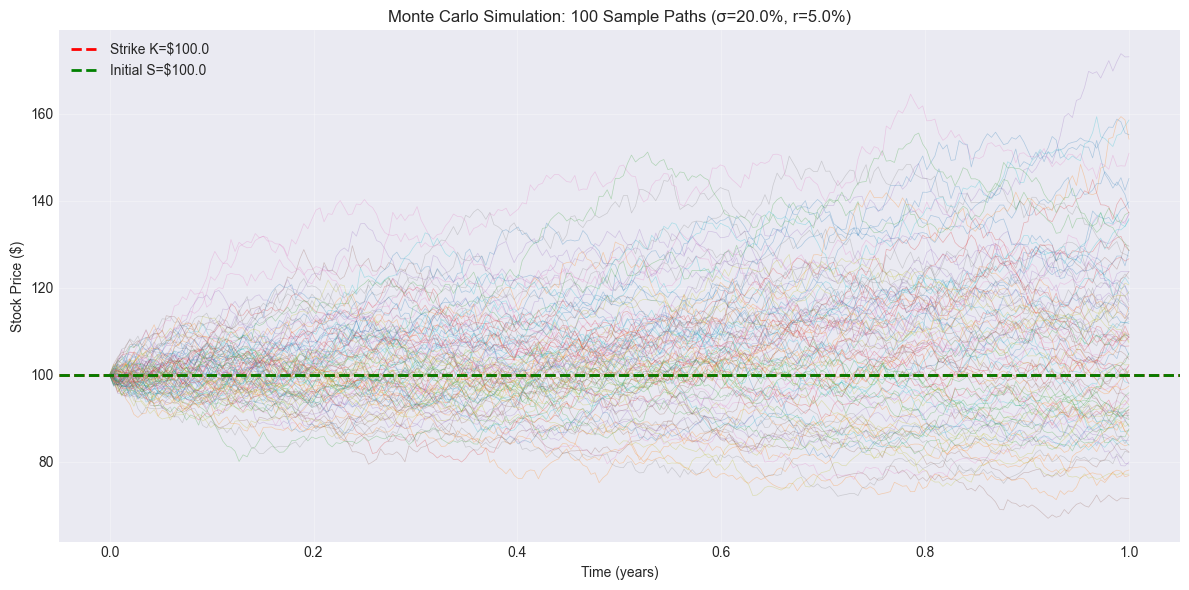

In [46]:
def generate_stock_paths(S0, T, r, sigma, n_simulations, n_steps, device):
    dt = T / n_steps
    Z = torch.randn(n_simulations, n_steps, device=device)
    
    drift = (r - 0.5 * sigma**2) * dt
    diffusion = sigma * np.sqrt(dt)
    
    log_returns = drift + diffusion * Z
    cumulative_log_returns = torch.cumsum(log_returns, dim=1)
    
    paths = S0 * torch.exp(cumulative_log_returns)
    S0_column = torch.full((n_simulations, 1), S0, device=device)
    paths = torch.cat([S0_column, paths], dim=1)
    
    return paths


S0 = 100.0
K = 100.0
T = 1.0
r = 0.05
sigma = 0.20
n_simulations = 10000
n_steps = 252

start_time = time.time()
paths = generate_stock_paths(S0, T, r, sigma, n_simulations, n_steps, device)
elapsed_time = time.time() - start_time

print(f"Generated {n_simulations:,} paths in {elapsed_time:.4f} seconds")
print(f"Shape: {paths.shape}")

final_prices = paths[:, -1].cpu().numpy()
expected_price = S0 * np.exp(r * T)

print(f"\nFinal Price Statistics:")
print(f"  Mean: ${final_prices.mean():.2f} (Expected: ${expected_price:.2f})")
print(f"  Std:  ${final_prices.std():.2f}")
print(f"  Min:  ${final_prices.min():.2f}")
print(f"  Max:  ${final_prices.max():.2f}")

plt.figure(figsize=(12, 6))
time_points = np.linspace(0, T, n_steps + 1)
sample_paths = paths[:100].cpu().numpy()

for i in range(100):
    plt.plot(time_points, sample_paths[i], alpha=0.3, linewidth=0.5)

plt.axhline(y=K, color='r', linestyle='--', linewidth=2, label=f'Strike K=${K}')
plt.axhline(y=S0, color='g', linestyle='--', linewidth=2, label=f'Initial S=${S0}')
plt.xlabel('Time (years)')
plt.ylabel('Stock Price ($)')
plt.title(f'Monte Carlo Simulation: 100 Sample Paths (σ={sigma*100}%, r={r*100}%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
def price_european_option(S0, K, T, r, sigma, option_type, n_simulations, device):
    n_steps = 1
    paths = generate_stock_paths(S0, T, r, sigma, n_simulations, n_steps, device)
    S_T = paths[:, -1]
    
    if option_type.lower() == 'call':
        payoffs = torch.maximum(S_T - K, torch.tensor(0.0, device=device))
    elif option_type.lower() == 'put':
        payoffs = torch.maximum(K - S_T, torch.tensor(0.0, device=device))
    else:
        raise ValueError("option_type must be 'call' or 'put'")
    
    discount_factor = np.exp(-r * T)
    discounted_payoffs = discount_factor * payoffs
    
    option_price = torch.mean(discounted_payoffs).item()
    std_dev = torch.std(discounted_payoffs).item()
    std_error = std_dev / np.sqrt(n_simulations)
    
    conf_interval = (option_price - 1.96 * std_error, 
                     option_price + 1.96 * std_error)
    
    payoff_stats = {
        'mean_payoff': torch.mean(payoffs).item(),
        'max_payoff': torch.max(payoffs).item(),
        'min_payoff': torch.min(payoffs).item(),
        'pct_in_the_money': (payoffs > 0).float().mean().item() * 100
    }
    
    return {
        'price': option_price,
        'std_error': std_error,
        'conf_interval': conf_interval,
        'payoff_stats': payoff_stats,
        'discount_factor': discount_factor
    }


print("EUROPEAN OPTIONS PRICING")
print("=" * 70)

start_time = time.time()
call_result = price_european_option(S0, K, T, r, sigma, 'call', 1000000, device)
call_time = time.time() - start_time

print(f"\nCALL OPTION (S=${S0}, K=${K}, T={T}yr, r={r*100}%, σ={sigma*100}%)")
print(f"  Price:              ${call_result['price']:.4f}")
print(f"  Std Error:          ${call_result['std_error']:.4f}")
print(f"  95% CI:             [${call_result['conf_interval'][0]:.4f}, ${call_result['conf_interval'][1]:.4f}]")
print(f"  Mean Payoff:        ${call_result['payoff_stats']['mean_payoff']:.4f}")
print(f"  % In-the-Money:     {call_result['payoff_stats']['pct_in_the_money']:.2f}%")
print(f"  Computation Time:   {call_time:.4f}s")

start_time = time.time()
put_result = price_european_option(S0, K, T, r, sigma, 'put', 1000000, device)
put_time = time.time() - start_time

print(f"\nPUT OPTION (S=${S0}, K=${K}, T={T}yr, r={r*100}%, σ={sigma*100}%)")
print(f"  Price:              ${put_result['price']:.4f}")
print(f"  Std Error:          ${put_result['std_error']:.4f}")
print(f"  95% CI:             [${put_result['conf_interval'][0]:.4f}, ${put_result['conf_interval'][1]:.4f}]")
print(f"  Mean Payoff:        ${put_result['payoff_stats']['mean_payoff']:.4f}")
print(f"  % In-the-Money:     {put_result['payoff_stats']['pct_in_the_money']:.2f}%")


pcp_lhs = call_result['price'] - put_result['price']
pcp_rhs = S0 - K * np.exp(-r * T)

print(f"\nPUT-CALL PARITY")
print(f"  C - P =             ${pcp_lhs:.4f}")
print(f"  S - K*e^(-rT) =     ${pcp_rhs:.4f}")
print(f"  Difference:         ${abs(pcp_lhs - pcp_rhs):.4f}")


EUROPEAN OPTIONS PRICING

CALL OPTION (S=$100.0, K=$100.0, T=1.0yr, r=5.0%, σ=20.0%)
  Price:              $10.4324
  Std Error:          $0.0147
  95% CI:             [$10.4035, $10.4612]
  Mean Payoff:        $10.9672
  % In-the-Money:     55.97%
  Computation Time:   0.2034s

PUT OPTION (S=$100.0, K=$100.0, T=1.0yr, r=5.0%, σ=20.0%)
  Price:              $5.5914
  Std Error:          $0.0087
  95% CI:             [$5.5744, $5.6084]
  Mean Payoff:        $5.8781
  % In-the-Money:     44.16%

PUT-CALL PARITY
  C - P =             $4.8410
  S - K*e^(-rT) =     $4.8771
  Difference:         $0.0361


BLACK-SCHOLES vs MONTE CARLO

Black-Scholes Prices
  Call: $10.4506
  Put:  $5.5735

Simulations     MC Price     BS Price     % Error
----------------------------------------------------------------------
        1,000  $   10.4814  $   10.4506    0.2947%
       10,000  $   10.2488  $   10.4506    1.9309%
      100,000  $   10.4638  $   10.4506    0.1263%
      500,000  $   10.4397  $   10.4506    0.1037%
    1,000,000  $   10.4597  $   10.4506    0.0871%


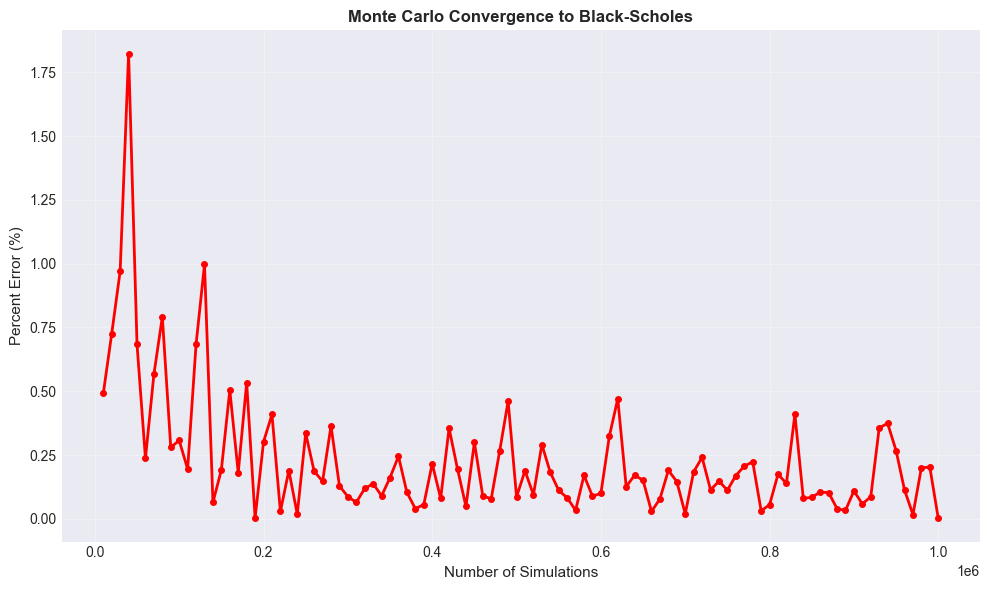

In [48]:
def black_scholes_price(S0, K, T, r, sigma, option_type):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type.lower() == 'call':
        price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type.lower() == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
    else:
        raise ValueError("option_type must be 'call' or 'put'")
    
    return price


print("BLACK-SCHOLES vs MONTE CARLO")
print("=" * 70)

bs_call = black_scholes_price(S0, K, T, r, sigma, 'call')
bs_put = black_scholes_price(S0, K, T, r, sigma, 'put')

print(f"\nBlack-Scholes Prices")
print(f"  Call: ${bs_call:.4f}")
print(f"  Put:  ${bs_put:.4f}")

simulation_counts = [1000, 10000, 100000, 500000, 1000000]

print(f"\n{'Simulations':<15} {'MC Price':<12} {'BS Price':<12} {'% Error'}")
print("-" * 70)

pct_errors = []

for n_sims in simulation_counts:
    mc_result = price_european_option(S0, K, T, r, sigma, 'call', n_sims, device)
    
    mc_price = mc_result['price']
    error = abs(mc_price - bs_call)
    pct_error = (error / bs_call) * 100
    
    pct_errors.append(pct_error)
    
    print(f"{n_sims:>13,}  ${mc_price:>10.4f}  ${bs_call:>10.4f}  {pct_error:>8.4f}%")

graph_simulations = list(range(10000, 1010000, 10000))
graph_pct_errors = []

for n_sims in graph_simulations:
    mc_result = price_european_option(S0, K, T, r, sigma, 'call', n_sims, device)
    mc_price = mc_result['price']
    error = abs(mc_price - bs_call)
    pct_error = (error / bs_call) * 100
    graph_pct_errors.append(pct_error)

plt.figure(figsize=(10, 6))

plt.plot(graph_simulations, graph_pct_errors, 'ro-', linewidth=2, markersize=4)
plt.xlabel('Number of Simulations', fontsize=11)
plt.ylabel('Percent Error (%)', fontsize=11)
plt.title('Monte Carlo Convergence to Black-Scholes', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [49]:
def calculate_greeks_mc(S0, K, T, r, sigma, option_type, n_simulations, device):
    h_pct = 0.01
    
    base_price = price_european_option(S0, K, T, r, sigma, option_type, 
                                       n_simulations, device)['price']
    
    h_S = S0 * h_pct
    price_up_S = price_european_option(S0 + h_S, K, T, r, sigma, option_type, 
                                       n_simulations, device)['price']
    price_down_S = price_european_option(S0 - h_S, K, T, r, sigma, option_type, 
                                         n_simulations, device)['price']
    
    delta = (price_up_S - price_down_S) / (2 * h_S)
    gamma = (price_up_S - 2 * base_price + price_down_S) / (h_S ** 2)
    
    h_sigma = 0.01
    price_up_sigma = price_european_option(S0, K, T, r, sigma + h_sigma, 
                                           option_type, n_simulations, device)['price']
    vega = (price_up_sigma - base_price) / (h_sigma * 100)
    
    h_T = 1/365
    if T > h_T:
        price_down_T = price_european_option(S0, K, T - h_T, r, sigma, 
                                             option_type, n_simulations, device)['price']
        theta = -(base_price - price_down_T)
    else:
        theta = np.nan
    
    h_r = 0.01
    price_up_r = price_european_option(S0, K, T, r + h_r, sigma, 
                                       option_type, n_simulations, device)['price']
    rho = (price_up_r - base_price) / (h_r * 100)
    
    return {
        'price': base_price,
        'delta': delta,
        'gamma': gamma,
        'vega': vega,
        'theta': theta,
        'rho': rho
    }


def black_scholes_greeks(S0, K, T, r, sigma, option_type):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    phi_d1 = norm.pdf(d1)
    
    if option_type.lower() == 'call':
        delta = norm.cdf(d1)
        theta = (-S0 * phi_d1 * sigma / (2 * np.sqrt(T)) 
                - r * K * np.exp(-r * T) * norm.cdf(d2))
        rho = K * T * np.exp(-r * T) * norm.cdf(d2)
    else:
        delta = -norm.cdf(-d1)
        theta = (-S0 * phi_d1 * sigma / (2 * np.sqrt(T)) 
                + r * K * np.exp(-r * T) * norm.cdf(-d2))
        rho = -K * T * np.exp(-r * T) * norm.cdf(-d2)
    
    gamma = phi_d1 / (S0 * sigma * np.sqrt(T))
    vega = S0 * phi_d1 * np.sqrt(T)
    
    return {
        'delta': delta,
        'gamma': gamma,
        'vega': vega / 100,
        'theta': theta / 365,
        'rho': rho / 100
    }


print("GREEKS CALCULATION")
print("=" * 70)

print("\nCALL OPTION GREEKS")
print("-" * 70)
mc_greeks_call = calculate_greeks_mc(S0, K, T, r, sigma, 'call', 200000, device)
bs_greeks_call = black_scholes_greeks(S0, K, T, r, sigma, 'call')

print(f"\n{'Greek':<10} {'Monte Carlo':<15} {'Black-Scholes':<15} {'Difference'}")
print("-" * 70)
print(f"{'Price':<10} ${mc_greeks_call['price']:<14.4f} ${bs_call:<14.4f} "
      f"${abs(mc_greeks_call['price'] - bs_call):.4f}")
print(f"{'Delta':<10} {mc_greeks_call['delta']:<15.4f} {bs_greeks_call['delta']:<15.4f} "
      f"{abs(mc_greeks_call['delta'] - bs_greeks_call['delta']):.4f}")
print(f"{'Gamma':<10} {mc_greeks_call['gamma']:<15.4f} {bs_greeks_call['gamma']:<15.4f} "
      f"{abs(mc_greeks_call['gamma'] - bs_greeks_call['gamma']):.4f}")
print(f"{'Vega':<10} {mc_greeks_call['vega']:<15.4f} {bs_greeks_call['vega']:<15.4f} "
      f"{abs(mc_greeks_call['vega'] - bs_greeks_call['vega']):.4f}")
print(f"{'Theta':<10} {mc_greeks_call['theta']:<15.4f} {bs_greeks_call['theta']:<15.4f} "
      f"{abs(mc_greeks_call['theta'] - bs_greeks_call['theta']):.4f}")
print(f"{'Rho':<10} {mc_greeks_call['rho']:<15.4f} {bs_greeks_call['rho']:<15.4f} "
      f"{abs(mc_greeks_call['rho'] - bs_greeks_call['rho']):.4f}")

print("\n\nPUT OPTION GREEKS")
print("-" * 70)
mc_greeks_put = calculate_greeks_mc(S0, K, T, r, sigma, 'put', 200000, device)
bs_greeks_put = black_scholes_greeks(S0, K, T, r, sigma, 'put')

print(f"\n{'Greek':<10} {'Monte Carlo':<15} {'Black-Scholes':<15} {'Difference'}")
print("-" * 70)
print(f"{'Price':<10} ${mc_greeks_put['price']:<14.4f} ${bs_put:<14.4f} "
      f"${abs(mc_greeks_put['price'] - bs_put):.4f}")
print(f"{'Delta':<10} {mc_greeks_put['delta']:<15.4f} {bs_greeks_put['delta']:<15.4f} "
      f"{abs(mc_greeks_put['delta'] - bs_greeks_put['delta']):.4f}")
print(f"{'Gamma':<10} {mc_greeks_put['gamma']:<15.4f} {bs_greeks_put['gamma']:<15.4f} "
      f"{abs(mc_greeks_put['gamma'] - bs_greeks_put['gamma']):.4f}")
print(f"{'Vega':<10} {mc_greeks_put['vega']:<15.4f} {bs_greeks_put['vega']:<15.4f} "
      f"{abs(mc_greeks_put['vega'] - bs_greeks_put['vega']):.4f}")
print(f"{'Theta':<10} {mc_greeks_put['theta']:<15.4f} {bs_greeks_put['theta']:<15.4f} "
      f"{abs(mc_greeks_put['theta'] - bs_greeks_put['theta']):.4f}")
print(f"{'Rho':<10} {mc_greeks_put['rho']:<15.4f} {bs_greeks_put['rho']:<15.4f} "
      f"{abs(mc_greeks_put['rho'] - bs_greeks_put['rho']):.4f}")


GREEKS CALCULATION

CALL OPTION GREEKS
----------------------------------------------------------------------

Greek      Monte Carlo     Black-Scholes   Difference
----------------------------------------------------------------------
Price      $10.4685        $10.4506        $0.0179
Delta      0.6804          0.6368          0.0435
Gamma      -0.0420         0.0188          0.0607
Vega       0.3729          0.3752          0.0023
Theta      -0.0430         -0.0176         0.0255
Rho        0.4864          0.5323          0.0459


PUT OPTION GREEKS
----------------------------------------------------------------------

Greek      Monte Carlo     Black-Scholes   Difference
----------------------------------------------------------------------
Price      $5.5817         $5.5735         $0.0082
Delta      -0.3922         -0.3632         0.0291
Gamma      0.0121          0.0188          0.0066
Vega       0.3646          0.3752          0.0106
Theta      -0.0248         -0.0045         0.

AMERICAN OPTIONS PRICING

American Put Price:  $6.0471
European Put Price:  $5.5493

American Call Price: $10.4563
European Call Price: $10.4382


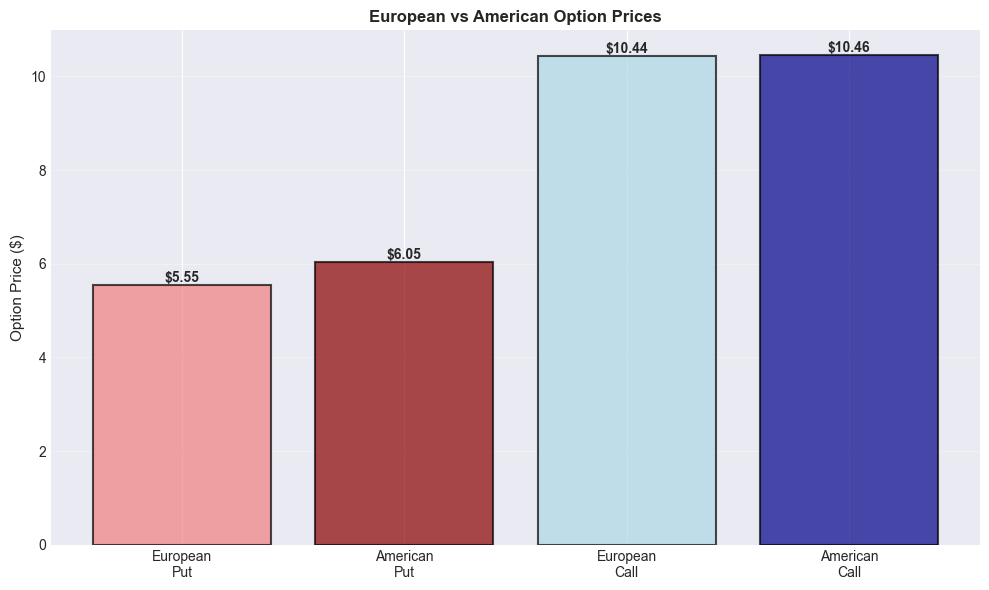

In [54]:
def price_american_option(S0, K, T, r, sigma, option_type, n_simulations, n_steps, device):
    paths = generate_stock_paths(S0, T, r, sigma, n_simulations, n_steps, device)
    
    if option_type.lower() == 'call':
        intrinsic_values = torch.maximum(paths - K, torch.tensor(0.0, device=device))
    elif option_type.lower() == 'put':
        intrinsic_values = torch.maximum(K - paths, torch.tensor(0.0, device=device))
    else:
        raise ValueError("option_type must be 'call' or 'put'")
    
    cash_flows = intrinsic_values[:, -1].clone()
    
    dt = T / n_steps
    discount = torch.exp(torch.tensor(-r * dt, device=device))
    
    exercise_times = torch.full((n_simulations,), n_steps, device=device)
    
    for t in range(n_steps - 1, 0, -1):
        itm_mask = intrinsic_values[:, t] > 0
        
        if itm_mask.sum() == 0:
            cash_flows = cash_flows * discount
            continue
        
        S_itm = paths[itm_mask, t]
        future_cf_itm = cash_flows[itm_mask]
        
        X = torch.stack([
            torch.ones_like(S_itm),
            S_itm,
            S_itm ** 2
        ], dim=1)
        
        Y = discount * future_cf_itm
        
        try:
            solution = torch.linalg.lstsq(X, Y)
            beta = solution.solution
            
            continuation_value = torch.zeros(n_simulations, device=device)
            continuation_value[itm_mask] = X @ beta
            
        except:
            continuation_value = torch.zeros(n_simulations, device=device)
            continuation_value[itm_mask] = Y.mean()
        
        exercise_now = intrinsic_values[:, t] > continuation_value
        
        cash_flows[exercise_now] = intrinsic_values[exercise_now, t]
        cash_flows[~exercise_now] = cash_flows[~exercise_now] * discount
        exercise_times[exercise_now & (exercise_times == n_steps)] = t
    
    option_price = torch.mean(cash_flows).item()
    std_error = torch.std(cash_flows).item() / np.sqrt(n_simulations)
    
    exercise_times_np = exercise_times.cpu().numpy()
    early_exercise_pct = (exercise_times_np < n_steps).mean() * 100
    
    time_values = (exercise_times_np / n_steps * T)
    avg_exercise_time = time_values[exercise_times_np < n_steps].mean() if early_exercise_pct > 0 else T
    
    return {
        'price': option_price,
        'std_error': std_error,
        'early_exercise_pct': early_exercise_pct,
        'avg_exercise_time': avg_exercise_time,
        'exercise_times': exercise_times_np
    }


print("AMERICAN OPTIONS PRICING")
print("=" * 70)

american_put = price_american_option(S0, K, T, r, sigma, 'put', 
                                     n_simulations=100000, n_steps=50, device=device)
european_put_price = price_european_option(S0, K, T, r, sigma, 'put', 100000, device)['price']

print(f"\nAmerican Put Price:  ${american_put['price']:.4f}")
print(f"European Put Price:  ${european_put_price:.4f}")

american_call = price_american_option(S0, K, T, r, sigma, 'call', 
                                      n_simulations=100000, n_steps=50, device=device)
european_call_price = price_european_option(S0, K, T, r, sigma, 'call', 100000, device)['price']

print(f"\nAmerican Call Price: ${american_call['price']:.4f}")
print(f"European Call Price: ${european_call_price:.4f}")

plt.figure(figsize=(10, 6))

categories = ['European\nPut', 'American\nPut', 'European\nCall', 'American\nCall']
prices = [european_put_price, american_put['price'], 
          european_call_price, american_call['price']]
colors = ['lightcoral', 'darkred', 'lightblue', 'darkblue']

bars = plt.bar(categories, prices, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
plt.ylabel('Option Price ($)', fontsize=11)
plt.title('European vs American Option Prices', fontsize=12, fontweight='bold')
plt.grid(True, axis='y', alpha=0.3)

for bar, price in zip(bars, prices):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'${price:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

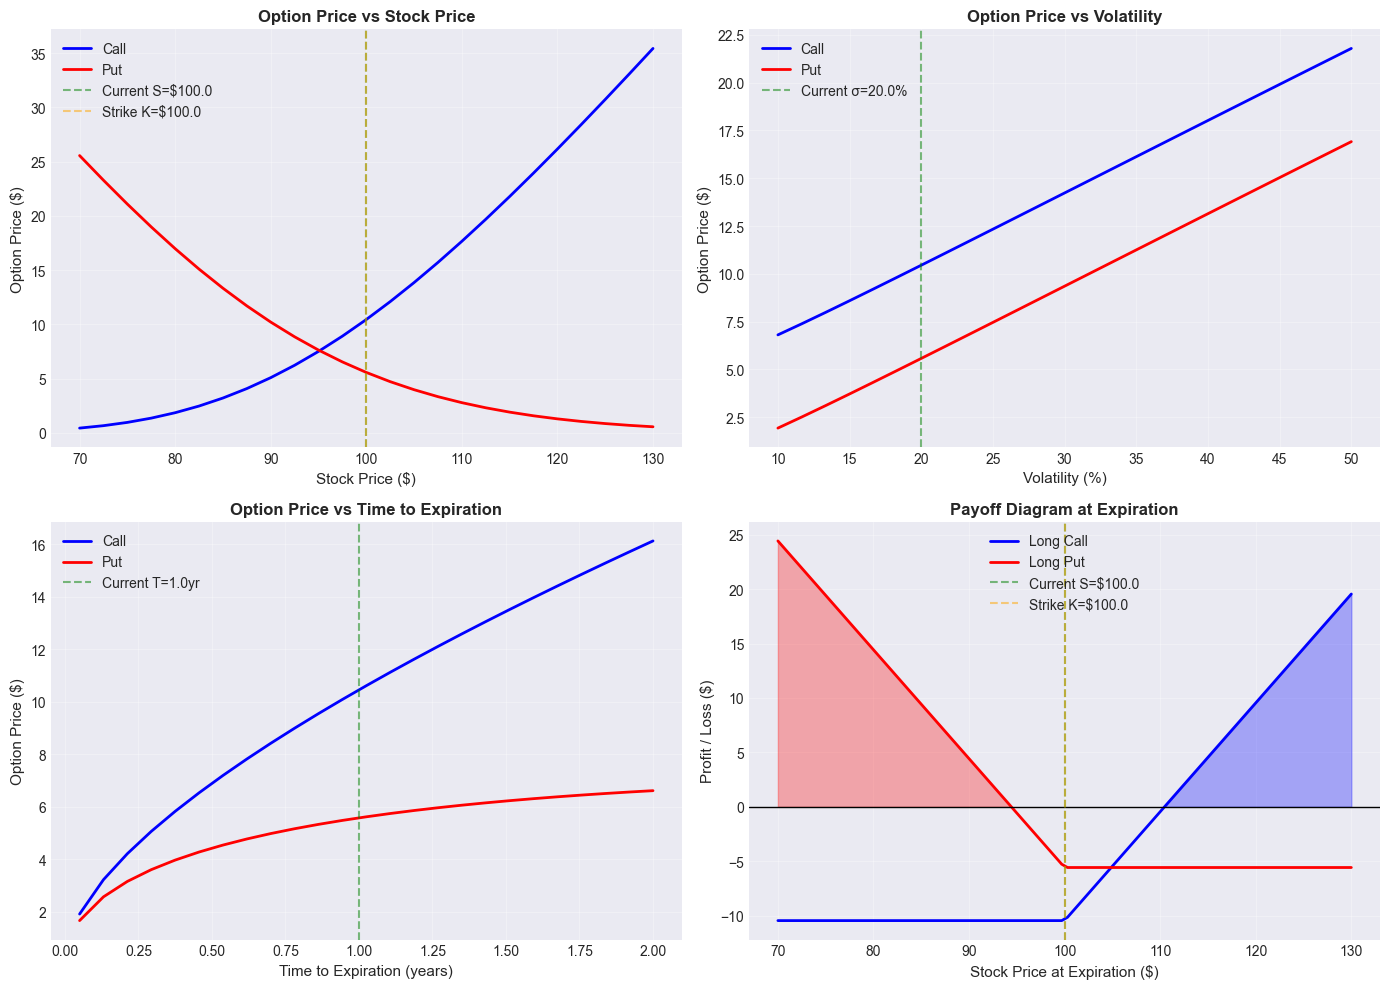

In [51]:


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

stock_prices = np.linspace(70, 130, 25)
call_prices_stock = []
put_prices_stock = []

for S in stock_prices:
    call_price = black_scholes_price(S, K, T, r, sigma, 'call')
    put_price = black_scholes_price(S, K, T, r, sigma, 'put')
    call_prices_stock.append(call_price)
    put_prices_stock.append(put_price)

ax1 = axes[0, 0]
ax1.plot(stock_prices, call_prices_stock, 'b-', linewidth=2, label='Call')
ax1.plot(stock_prices, put_prices_stock, 'r-', linewidth=2, label='Put')
ax1.axvline(S0, color='green', linestyle='--', alpha=0.5, label=f'Current S=${S0}')
ax1.axvline(K, color='orange', linestyle='--', alpha=0.5, label=f'Strike K=${K}')
ax1.set_xlabel('Stock Price ($)', fontsize=11)
ax1.set_ylabel('Option Price ($)', fontsize=11)
ax1.set_title('Option Price vs Stock Price', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

volatilities = np.linspace(0.1, 0.5, 25)
call_prices_vol = []
put_prices_vol = []

for vol in volatilities:
    call_price = black_scholes_price(S0, K, T, r, vol, 'call')
    put_price = black_scholes_price(S0, K, T, r, vol, 'put')
    call_prices_vol.append(call_price)
    put_prices_vol.append(put_price)

ax2 = axes[0, 1]
ax2.plot(volatilities * 100, call_prices_vol, 'b-', linewidth=2, label='Call')
ax2.plot(volatilities * 100, put_prices_vol, 'r-', linewidth=2, label='Put')
ax2.axvline(sigma * 100, color='green', linestyle='--', alpha=0.5, label=f'Current σ={sigma*100}%')
ax2.set_xlabel('Volatility (%)', fontsize=11)
ax2.set_ylabel('Option Price ($)', fontsize=11)
ax2.set_title('Option Price vs Volatility', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

times = np.linspace(0.05, 2.0, 25)
call_prices_time = []
put_prices_time = []

for t in times:
    call_price = black_scholes_price(S0, K, t, r, sigma, 'call')
    put_price = black_scholes_price(S0, K, t, r, sigma, 'put')
    call_prices_time.append(call_price)
    put_prices_time.append(put_price)

ax3 = axes[1, 0]
ax3.plot(times, call_prices_time, 'b-', linewidth=2, label='Call')
ax3.plot(times, put_prices_time, 'r-', linewidth=2, label='Put')
ax3.axvline(T, color='green', linestyle='--', alpha=0.5, label=f'Current T={T}yr')
ax3.set_xlabel('Time to Expiration (years)', fontsize=11)
ax3.set_ylabel('Option Price ($)', fontsize=11)
ax3.set_title('Option Price vs Time to Expiration', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

S_range = np.linspace(70, 130, 100)
call_payoff = np.maximum(S_range - K, 0)
put_payoff = np.maximum(K - S_range, 0)

call_cost = black_scholes_price(S0, K, T, r, sigma, 'call')
put_cost = black_scholes_price(S0, K, T, r, sigma, 'put')

call_profit = call_payoff - call_cost
put_profit = put_payoff - put_cost

ax4 = axes[1, 1]
ax4.plot(S_range, call_profit, 'b-', linewidth=2, label='Long Call')
ax4.plot(S_range, put_profit, 'r-', linewidth=2, label='Long Put')
ax4.axhline(0, color='black', linestyle='-', linewidth=1)
ax4.axvline(S0, color='green', linestyle='--', alpha=0.5, label=f'Current S=${S0}')
ax4.axvline(K, color='orange', linestyle='--', alpha=0.5, label=f'Strike K=${K}')
ax4.fill_between(S_range, 0, call_profit, where=(call_profit > 0), alpha=0.3, color='blue')
ax4.fill_between(S_range, 0, put_profit, where=(put_profit > 0), alpha=0.3, color='red')
ax4.set_xlabel('Stock Price at Expiration ($)', fontsize=11)
ax4.set_ylabel('Profit / Loss ($)', fontsize=11)
ax4.set_title('Payoff Diagram at Expiration', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [52]:
import pandas as pd

S0_input = 100.0
K_input = 100.0
T_input = 1.0
r_input = 0.05
sigma_input = 0.20
n_sims = 500000

print(f"\nInput Parameters:")
print(f"  Stock Price (S):      ${S0_input:.2f}")
print(f"  Strike Price (K):     ${K_input:.2f}")
print(f"  Time to Expiry (T):   {T_input:.2f} years")
print(f"  Risk-free Rate (r):   {r_input*100:.2f}%")
print(f"  Volatility (σ):       {sigma_input*100:.2f}%")
print(f"  Simulations:          {n_sims:,}")

euro_call = price_european_option(S0_input, K_input, T_input, r_input, sigma_input, 'call', n_sims, device)
euro_put = price_european_option(S0_input, K_input, T_input, r_input, sigma_input, 'put', n_sims, device)

amer_call = price_american_option(S0_input, K_input, T_input, r_input, sigma_input, 'call', n_sims, 50, device)
amer_put = price_american_option(S0_input, K_input, T_input, r_input, sigma_input, 'put', n_sims, 50, device)

bs_call = black_scholes_price(S0_input, K_input, T_input, r_input, sigma_input, 'call')
bs_put = black_scholes_price(S0_input, K_input, T_input, r_input, sigma_input, 'put')

print("\n" + "=" * 70)
print("OPTION PRICES")
print("=" * 70)

prices_df = pd.DataFrame({
    'Option Type': ['European Call', 'European Put', 'American Call', 'American Put'],
    'Monte Carlo': [euro_call['price'], euro_put['price'], amer_call['price'], amer_put['price']],
    'Black-Scholes': [bs_call, bs_put, bs_call, bs_put],
    'Difference': [
        abs(euro_call['price'] - bs_call),
        abs(euro_put['price'] - bs_put),
        abs(amer_call['price'] - bs_call),
        abs(amer_put['price'] - bs_put)
    ]
})

print("\n" + prices_df.to_string(index=False))
print("\n" + "=" * 70)


Input Parameters:
  Stock Price (S):      $100.00
  Strike Price (K):     $100.00
  Time to Expiry (T):   1.00 years
  Risk-free Rate (r):   5.00%
  Volatility (σ):       20.00%
  Simulations:          500,000

OPTION PRICES

  Option Type  Monte Carlo  Black-Scholes  Difference
European Call    10.469610      10.450584    0.019027
 European Put     5.584597       5.573526    0.011071
American Call    10.497408      10.450584    0.046824
 American Put     6.047468       5.573526    0.473942

